# Chapter 13: Auxiliaries, Parameters, and Decision Rules

*Systems Thinking with AI* by Jason Karpeles

Four kinds of quantity share one notation, and each needs its own evidence and its own test.

**Goal.** Four small calculations run through the chapter's whitelisted evaluator. A decision rule that never asks for a negative adjustment, a belief that lags what is observed, the names an expression reads and what happens when one has no value, and an auxiliary tested by plain arithmetic.

**Demonstrations**

1. A decision rule that never goes negative
2. A belief that lags the truth
3. Dependencies fall out of the parse
4. An auxiliary is tested by arithmetic

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/13-expressions/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/13-expressions/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [2]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 13 reader: auxiliaries, parameters, perceptions and decision rules as algebra.

Every number comes from the Chapter 13 pack (evaluate, variables, parse) so the
reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed, undefined

from chapters.chapter_13_expressions.code.expressions import (
    UnsafeExpression,
    evaluate,
    parse,
    variables,
)

EQ_GAP = "max(0, demand - capacity) / adjustment"
EQ_EXPECT = "expected = expected + (observed - expected) / smoothing_time"
EQ_BACKLOG = "backlog / production_delay + safety"
EQ_HIRING = "hiring_rate = (desired_workforce - workforce) / hiring_delay"
EQ_COVER = "inventory / shipment_rate"

CAPACITY = 100.0


# Demonstration 1: a guarded decision rule, evaluated through the whitelist.

def guarded_gap(demand=120.0, adjustment=4.0):
    def rate(d):
        return evaluate(EQ_GAP, {"demand": d, "capacity": CAPACITY, "adjustment": adjustment})

    value = rate(demand)
    grid = np.linspace(60, 160, 51)
    curve = [rate(d) for d in grid]
    try:
        parse("round(3.7)")
        refused = "accepted"
    except UnsafeExpression as exc:
        refused = str(exc)

    fig, ax = new_figure()
    ax.plot(grid, curve, color=PALETTE["navy"])
    ax.plot([demand], [value], marker="o", markersize=10, color=PALETTE["terracotta"])
    ax.axvline(CAPACITY, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    label_point(ax, CAPACITY, 36 / adjustment * 0.9, "capacity 100", color=PALETTE["grey"], dx=-6, dy=0, ha="right")
    label_point(ax, demand, value, fmt(value, 1), color=PALETTE["terracotta"],
                dx=(10 if demand < 130 else -10), dy=(8 if demand >= 100 else 10), ha=("left" if demand < 130 else "right"))
    ax.set_xlim(60, 160)
    ax.set_ylim(-1, 16)
    ax.set_xlabel("Demand")
    ax.set_ylabel("Adjustment rate")

    gap = demand - CAPACITY
    if gap <= 0:
        tail = ("The gap is " + ("exactly zero, a tie between demand and capacity," if gap == 0 else "negative,")
                + " so max(0, gap) returns 0 and the rule orders no adjustment; it never asks for a negative one.")
    else:
        tail = "The gap is positive, so the rule asks for one adjustment-time share of it."
    metrics = {
        "Gap (demand - capacity)": signed(gap, 0),
        "Adjustment rate": (fmt(value, 2) if abs(round(value * 100) % 10 - 5) == 0 and abs(value * 100 - round(value * 100)) < 1e-9 else fmt(value, 1)),
        "Round(3.7) in a model expression": refused,
    }
    interpretation = (
        f"max(0, {fmt(demand, 0)} - 100) / {fmt(adjustment, 0)} = max(0, {signed(gap, 0)}) / {fmt(adjustment, 0)} "
        f"= {fmt(max(0.0, gap), 0)} / {fmt(adjustment, 0)} = {fmt(value, 1)}. {tail}"
    )
    return fig, metrics, interpretation


# Demonstration 2: a perception has its own state.

def perception_lag(smoothing_time=4.0, direction="rise"):
    target = 120.0 if direction == "rise" else 80.0
    periods = 10
    observed = [100.0] + [target] * periods
    expected = [100.0]
    for k in range(1, periods + 1):
        expected.append(evaluate("expected + (observed - expected) / smoothing_time",
                                 {"expected": expected[-1], "observed": observed[k],
                                  "smoothing_time": smoothing_time}))
    t = np.arange(0, periods + 1)

    fig, ax = new_figure()
    ax.step(t, observed, where="post", color=PALETTE["grey"], linestyle="dashed")
    ax.plot(t, expected, marker="o", color=PALETTE["teal"])
    ax.set_xlim(-0.3, periods + 0.3)
    ax.set_ylim(70, 130)
    label_point(ax, periods, target, "observed", color=PALETTE["grey"], dx=-4,
                dy=(8 if direction == "rise" else -8), ha="right", va=("bottom" if direction == "rise" else "top"))
    label_point(ax, periods, expected[-1], f"expected {fmt(expected[-1], 1)}", color=PALETTE["teal"], dx=-4,
                dy=(-12 if direction == "rise" else 12), ha="right", va=("top" if direction == "rise" else "bottom"))
    ax.set_xlabel("Period")
    ax.set_ylabel("Demand")

    gap5 = target - expected[5]
    over = (max(expected) > target) if direction == "rise" else (min(expected) < target)
    metrics = {
        "Expected after period 1": fmt(expected[1], 1),
        "Expected after period 5": fmt(expected[5], 1),
        "Expected after period 10": fmt(expected[10], 1),
        "Gap to observed at period 5": signed(gap5, 1),
        "Overshoots the observed value": "yes" if over else "no",
    }
    interpretation = (
        f"First update: 100 + ({fmt(target, 0)} - 100) / {fmt(smoothing_time, 0)} = "
        f"{fmt(expected[1], 1)}. Each period closes 1 / {fmt(smoothing_time, 0)} of the remaining gap, so at "
        f"period 5 the belief is {fmt(expected[5], 1)}, still {signed(gap5, 1)} from {fmt(target, 0)}. "
        f"The belief approaches the observed value and does not overshoot it."
    )
    return fig, metrics, interpretation


# Demonstration 3: the names an expression reads are its dependency edges.

EXPRESSIONS = {
    "queue": ("backlog / production_delay + safety",
              {"backlog": 80.0, "production_delay": 4.0, "safety": 5.0}),
    "gap": ("max(0, demand - capacity) / adjustment",
            {"demand": 120.0, "capacity": 100.0, "adjustment": 4.0}),
    "hiring": ("(desired_workforce - workforce) / hiring_delay",
               {"desired_workforce": 60.0, "workforce": 50.0, "hiring_delay": 5.0}),
}


def dependency_edges(expression="queue", supply="all"):
    text, values = EXPRESSIONS[expression]
    names = sorted(variables(text))
    supplied = dict(values)
    dropped = None
    if supply == "one missing":
        dropped = names[-1]
        del supplied[dropped]
    try:
        result = evaluate(text, supplied)
        outcome = fmt(result, 2)
        failure = None
    except ValueError as exc:
        outcome = undefined("a name has no value")
        failure = str(exc)

    fig, ax = new_figure()
    ypos = np.arange(len(names))[::-1]
    for y, name in zip(ypos, names):
        if name in supplied:
            ax.barh(y, supplied[name], height=0.5, color=PALETTE["teal"])
            ax.annotate(fmt(supplied[name], 0), (supplied[name], y), xytext=(5, 0), textcoords="offset points",
                        va="center", fontsize=10.5)
        else:
            ax.annotate("no value supplied", (1, y), xytext=(0, 0), textcoords="offset points",
                        va="center", fontsize=10.5, color=PALETTE["terracotta"])
    ax.set_yticks(ypos, names)
    ax.set_xlim(0, 140)
    ax.set_ylim(-0.7, len(names) - 0.3)
    ax.set_xlabel("Value supplied")
    ax.set_ylabel("Name the expression reads")

    metrics = {
        "Expression": text,
        "Names read (dependency edges)": ", ".join(names),
        "Number of edges": len(names),
        "Result": outcome,
    }
    if failure is None:
        interpretation = (
            f"The parse finds {len(names)} names: {', '.join(names)}. With all of them supplied, "
            f"{_substitute(text, supplied)} = {fmt(result, 2)}."
        )
    else:
        interpretation = (
            f"The parse finds {len(names)} names: {', '.join(names)}. No value was supplied for {dropped}, "
            f"so evaluation stops instead of treating it as 0. Counting one value per name: {len(names)} x 1 = "
            f"{len(names)} values needed, {len(supplied)} supplied, so {len(names)} - {len(supplied)} = "
            f"{len(names) - len(supplied)} is missing, known before anything runs."
        )
    return fig, metrics, interpretation


def _substitute(text, values):
    out = text
    for name in sorted(values, key=len, reverse=True):
        out = out.replace(name, fmt(values[name], 0))
    return out


# Demonstration 4: testing an auxiliary by substitution.

def coverage_test(inventory=200.0, shipment_rate=50.0):
    target = 2.0
    try:
        coverage = evaluate(EQ_COVER, {"inventory": inventory, "shipment_rate": shipment_rate})
    except ZeroDivisionError:
        coverage = None

    fig, ax = new_figure()
    ax.axhline(target, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    label_point(ax, 0.5, target, "target coverage 2 weeks", color=PALETTE["grey"], dx=0, dy=6, ha="right")
    if coverage is None:
        ax.annotate("undefined: no shipments, so no weeks of cover", (0, 3), ha="center", fontsize=10.5,
                    color=PALETTE["terracotta"])
        height = 0.0
    else:
        height = coverage
        ax.bar([0], [coverage], width=0.5, color=PALETTE["teal"])
        ax.annotate(f"{fmt(coverage, 1)} weeks", (0, coverage), xytext=(0, 5), textcoords="offset points",
                    ha="center", fontsize=10.5)
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 9)
    ax.set_xticks([0], [f"inventory {fmt(inventory, 0)}, shipments {fmt(shipment_rate, 0)} per week"])
    ax.set_xlabel("Case under test")
    ax.set_ylabel("Inventory coverage (weeks)")

    if coverage is None:
        metrics = {"Inventory coverage": undefined("the shipment rate is zero"), "Target coverage": "2 weeks"}
        interpretation = (
            f"At 50 per week the same stock gives {fmt(inventory, 0)} / 50 = {fmt(inventory / 50, 1)} weeks, but at 0 "
            f"the quotient {fmt(inventory, 0)} / 0 has no value: it is undefined, not 0 weeks and not infinite cover. "
            f"A boundary test for this auxiliary should assert that case on purpose."
        )
    else:
        if coverage == target:
            rel = "exactly on the target, a tie"
        elif coverage > target:
            rel = f"{fmt(coverage - target, 1)} weeks above the target"
        else:
            rel = f"{fmt(target - coverage, 1)} weeks below the target"
        metrics = {
            "Inventory coverage": f"{fmt(coverage, 1)} weeks",
            "Target coverage": "2 weeks",
            "Against target": rel,
        }
        interpretation = (
            f"Coverage = {fmt(inventory, 0)} / {fmt(shipment_rate, 0)} = {fmt(coverage, 1)} weeks, {rel}. "
            f"An auxiliary has no state, so this arithmetic is its whole test."
        )
    return fig, metrics, interpretation


## 1. A decision rule that never goes negative

*What does a guarded gap rule do when demand is below capacity?*

The max(0, ...) guard turns every negative gap into zero, so the rule only reacts to a shortfall and the adjustment time divides the size of that reaction.

    max(0, demand - capacity) / adjustment

**Symbols and inputs.** demand and capacity are in the same units; the gap is demand minus capacity. adjustment is the time over which the gap is closed. The rate is the share of the gap acted on per period.

**Predict first.** With demand 80 and capacity 100, is the adjustment rate negative, zero or positive?

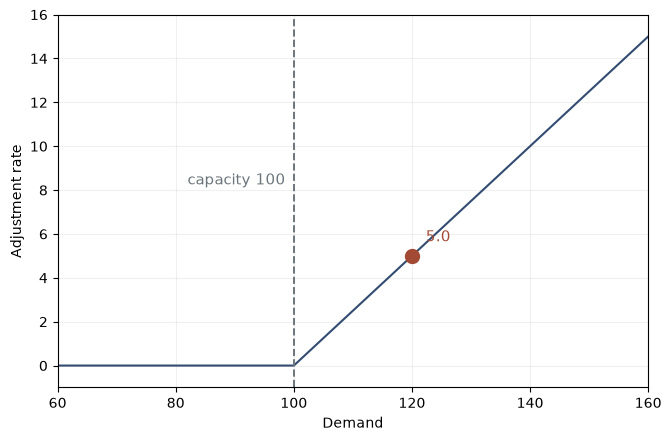

- **Gap (demand - capacity):** 20
- **Adjustment rate:** 5.0
- **Round(3.7) in a model expression:** 'round' is not an allowed function

max(0, 120 - 100) / 4 = max(0, 20) / 4 = 20 / 4 = 5.0. The gap is positive, so the rule asks for one adjustment-time share of it.

In [5]:
show(guarded_gap(demand=120.0, adjustment=4.0))

**Use the idea.** State what a rule may never output, and test it at the boundary where the gap is zero or negative.

**Where the conclusion applies.** Capacity fixed at 100 and a rule that fires every period. A real owner might act monthly, which would make this rule more responsive than the organization.

*Constructed example: the chapter's guarded expression with demand and adjustment values chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(guarded_gap, [('demand', [80.0, 100.0, 120.0, 150.0]), ('adjustment', [4.0, 8.0])])

- **demand = 80.0, adjustment = 4.0**: Gap (demand - capacity) (-20); Adjustment rate 0.0; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 80.0, adjustment = 8.0**: Gap (demand - capacity) (-20); Adjustment rate 0.0; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 100.0, adjustment = 4.0**: Gap (demand - capacity) 0; Adjustment rate 0.0; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 100.0, adjustment = 8.0**: Gap (demand - capacity) 0; Adjustment rate 0.0; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 120.0, adjustment = 4.0**: Gap (demand - capacity) 20; Adjustment rate 5.0; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 120.0, adjustment = 8.0**: Gap (demand - capacity) 20; Adjustment rate 2.5; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 150.0, adjustment = 4.0**: Gap (demand - capacity) 50; Adjustment rate 12.5; Round(3.7) in a model expression 'round' is not an allowed function
- **demand = 150.0, adjustment = 8.0**: Gap (demand - capacity) 50; Adjustment rate 6.25; Round(3.7) in a model expression 'round' is not an allowed function

## 2. A belief that lags the truth

*How far behind an observed step does a smoothed belief stay?*

Each period closes 1 / smoothing_time of the remaining gap, so a longer smoothing time leaves a larger gap for longer. The belief approaches the observed value without passing it.

    expected = expected + (observed - expected) / smoothing_time

**Symbols and inputs.** observed is the true demand from period 1 on, starting at 100. expected is the decider's belief and carries forward from period to period. smoothing_time is the number of periods over which the gap is closed: each period removes 1 / smoothing_time of what remains, so the gap shrinks but never fully closes.

**Predict first.** With a smoothing time of 8, is the belief closer to the observed value after 5 periods than with a time of 2?

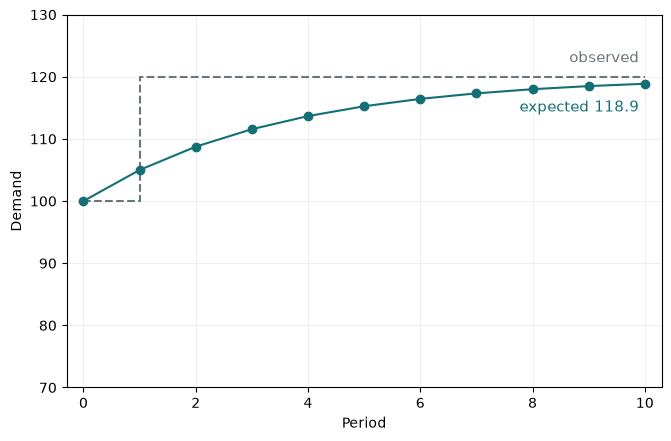

- **Expected after period 1:** 105.0
- **Expected after period 5:** 115.3
- **Expected after period 10:** 118.9
- **Gap to observed at period 5:** 4.7
- **Overshoots the observed value:** no

First update: 100 + (120 - 100) / 4 = 105.0. Each period closes 1 / 4 of the remaining gap, so at period 5 the belief is 115.3, still 4.7 from 120. The belief approaches the observed value and does not overshoot it.

In [7]:
show(perception_lag(smoothing_time=4.0, direction='rise'))

**Use the idea.** If the decider cannot see a quantity directly and at once, model the belief with its own state instead of reading the true value.

**Where the conclusion applies.** One step change from 100 and a belief that starts at the old value. A decider who also reads a trend or a pipeline would not lag in this way.

*Constructed example: the chapter's smoothing rule evaluated by the chapter's code, with the step size and smoothing times chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(perception_lag, [('smoothing_time', [2.0, 4.0, 8.0]), ('direction', ['rise', 'fall'])])

- **smoothing_time = 2.0, direction = rise**: Expected after period 1 110.0; Expected after period 5 119.4; Expected after period 10 120.0; Gap to observed at period 5 0.6; Overshoots the observed value no
- **smoothing_time = 2.0, direction = fall**: Expected after period 1 90.0; Expected after period 5 80.6; Expected after period 10 80.0; Gap to observed at period 5 (-0.6); Overshoots the observed value no
- **smoothing_time = 4.0, direction = rise**: Expected after period 1 105.0; Expected after period 5 115.3; Expected after period 10 118.9; Gap to observed at period 5 4.7; Overshoots the observed value no
- **smoothing_time = 4.0, direction = fall**: Expected after period 1 95.0; Expected after period 5 84.7; Expected after period 10 81.1; Gap to observed at period 5 (-4.7); Overshoots the observed value no
- **smoothing_time = 8.0, direction = rise**: Expected after period 1 102.5; Expected after period 5 109.7; Expected after period 10 114.7; Gap to observed at period 5 10.3; Overshoots the observed value no
- **smoothing_time = 8.0, direction = fall**: Expected after period 1 97.5; Expected after period 5 90.3; Expected after period 10 85.3; Gap to observed at period 5 (-10.3); Overshoots the observed value no

## 3. Dependencies fall out of the parse

*Which names does an expression read, and what happens when one has no value?*

Parsing yields the set of names read before anything runs. Evaluation then refuses a name with no value instead of substituting zero, so a missing quantity cannot pass as a zero one.

    backlog / production_delay + safety
    hiring_rate = (desired_workforce - workforce) / hiring_delay

**Symbols and inputs.** Each bar is the value supplied for one name the expression reads. The names read are the expression's edges in the model's dependency graph.

**Predict first.** If the last name in alphabetical order has no value, does evaluation return 0 for it?

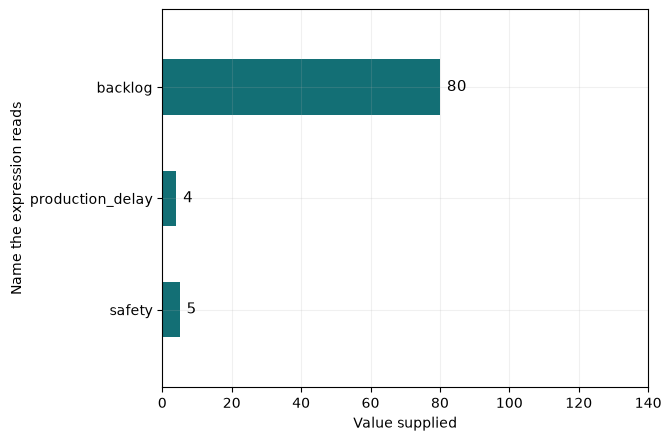

- **Expression:** backlog / production_delay + safety
- **Names read (dependency edges):** backlog, production_delay, safety
- **Number of edges:** 3
- **Result:** 25.00

The parse finds 3 names: backlog, production_delay, safety. With all of them supplied, 80 / 4 + 5 = 25.00.

In [9]:
show(dependency_edges(expression='queue', supply='all'))

**Use the idea.** Compare the names an expression reads with the names the model defines, and treat the difference as the list of what is missing.

**Where the conclusion applies.** Numeric values defined for this reader, one expression at a time. A cycle among auxiliaries is a separate defect, found by the compiler of a later chapter.

*Constructed example: the chapter's expressions with values defined for this reader and evaluated by the chapter's code.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(dependency_edges, [('expression', ['queue', 'gap', 'hiring']), ('supply', ['all', 'one missing'])])

- **expression = queue, supply = all**: Expression backlog / production_delay + safety; Names read (dependency edges) backlog, production_delay, safety; Number of edges 3; Result 25.00
- **expression = queue, supply = one missing**: Expression backlog / production_delay + safety; Names read (dependency edges) backlog, production_delay, safety; Number of edges 3; Result undefined (a name has no value)
- **expression = gap, supply = all**: Expression max(0, demand - capacity) / adjustment; Names read (dependency edges) adjustment, capacity, demand; Number of edges 3; Result 5.00
- **expression = gap, supply = one missing**: Expression max(0, demand - capacity) / adjustment; Names read (dependency edges) adjustment, capacity, demand; Number of edges 3; Result undefined (a name has no value)
- **expression = hiring, supply = all**: Expression (desired_workforce - workforce) / hiring_delay; Names read (dependency edges) desired_workforce, hiring_delay, workforce; Number of edges 3; Result 2.00
- **expression = hiring, supply = one missing**: Expression (desired_workforce - workforce) / hiring_delay; Names read (dependency edges) desired_workforce, hiring_delay, workforce; Number of edges 3; Result undefined (a name has no value)

## 4. An auxiliary is tested by arithmetic

*What are the cases worth testing for a coverage auxiliary?*

An auxiliary holds no state, so each input set has one expected value that plain division gives. The case worth adding is a zero denominator, which has no value at all.

    inventory / shipment_rate

**Symbols and inputs.** inventory is in units, shipment_rate in units per week, so coverage is in weeks. The target coverage of 2 weeks is a parameter.

**Predict first.** With 200 units and shipments of 100 per week, is coverage above or below the target of 2 weeks?

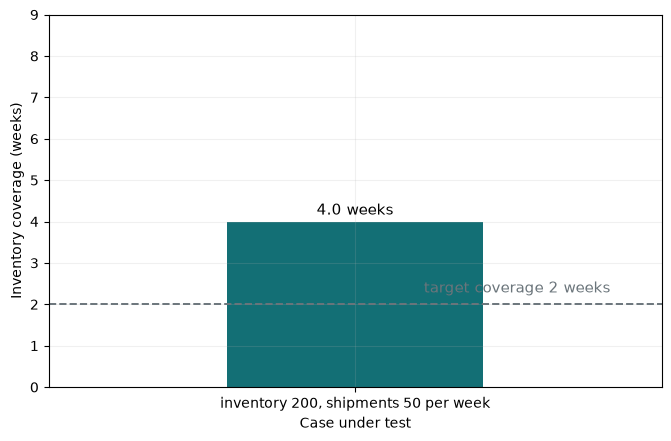

- **Inventory coverage:** 4.0 weeks
- **Target coverage:** 2 weeks
- **Against target:** 2.0 weeks above the target

Coverage = 200 / 50 = 4.0 weeks, 2.0 weeks above the target. An auxiliary has no state, so this arithmetic is its whole test.

In [11]:
show(coverage_test(inventory=200.0, shipment_rate=50.0))

**Use the idea.** Write the substitution test for every auxiliary, including the case where its denominator is zero.

**Where the conclusion applies.** A single week of shipments taken as the rate. If shipments swing, the coverage computed from one week is not the coverage over the next several.

*Constructed example: the chapter's two hundred units against fifty per week, with other inputs chosen for this reader.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(coverage_test, [('inventory', [200.0, 400.0]), ('shipment_rate', [0.0, 50.0, 100.0])])

- **inventory = 200.0, shipment_rate = 0.0**: Inventory coverage undefined (the shipment rate is zero); Target coverage 2 weeks
- **inventory = 200.0, shipment_rate = 50.0**: Inventory coverage 4.0 weeks; Target coverage 2 weeks; Against target 2.0 weeks above the target
- **inventory = 200.0, shipment_rate = 100.0**: Inventory coverage 2.0 weeks; Target coverage 2 weeks; Against target exactly on the target, a tie
- **inventory = 400.0, shipment_rate = 0.0**: Inventory coverage undefined (the shipment rate is zero); Target coverage 2 weeks
- **inventory = 400.0, shipment_rate = 50.0**: Inventory coverage 8.0 weeks; Target coverage 2 weeks; Against target 6.0 weeks above the target
- **inventory = 400.0, shipment_rate = 100.0**: Inventory coverage 4.0 weeks; Target coverage 2 weeks; Against target 2.0 weeks above the target

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With demand 150 and adjustment 8, what is the adjustment rate?

<details><summary>Answer</summary>

max(0, 150 - 100) / 8 = 50 / 8 = 6.25.

</details>

### Exercise 2

With a smoothing time of 2 and demand stepping from 100 to 120, what is the belief after the first period?

<details><summary>Answer</summary>

100 + (120 - 100) / 2 = 100 + 10 = 110.

</details>

### Exercise 3

For backlog / production_delay + safety with backlog 80, production_delay 4 and safety 5, what is the result?

<details><summary>Answer</summary>

80 / 4 + 5 = 20 + 5 = 25.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/